In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip '/content/drive/MyDrive/Copy of experience 4.zip'

Streaming output truncated to the last 5000 lines.
  inflating: experience 4/Group k_End/Ha_End/AHCR_00034_Ha_End_9.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00035_Ha_End_0.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00035_Ha_End_1.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00035_Ha_End_8.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00035_Ha_End_9.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00036_Ha_End_0.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00036_Ha_End_1.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00036_Ha_End_8.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00036_Ha_End_9.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00037_Ha_End_0.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00037_Ha_End_1.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00037_Ha_End_8.jpg  
  inflating: experience 4/Group k_End/Ha_End/AHCR_00037_Ha_End_9.jpg  
  inflating: experience 4/

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 4"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2121/2121 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.1140 - loss: 3.2043 - val_accuracy: 0.5353 - val_loss: 1.5653
Epoch 2/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.3966 - loss: 1.9652 - val_accuracy: 0.5916 - val_loss: 1.3339
Epoch 3/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 84s 22ms/step - accuracy: 0.4915 - loss: 1.6364 - val_accuracy: 0.6639 - val_loss: 1.1207
Epoch 4/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.5384 - loss: 1.4795 - val_accuracy: 0.6844 - val_loss: 1.0541
Epoch 5/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.5643 - loss: 1.3877 - val_accuracy: 0.7129 - val_loss: 0.9669
Epoch 6/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.5932 - loss: 1.3177 - val_accuracy: 0.7536 - val_loss: 0.8155
Epoch 7/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.6109 - loss: 1.2554 - val_accuracy: 0.7563 - val_loss: 0.8210
Epoch 8/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.6248 - loss: 1.20

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8102 - loss: 0.6438
Train Accuracy: 70.37%
Test Accuracy: 81.11%


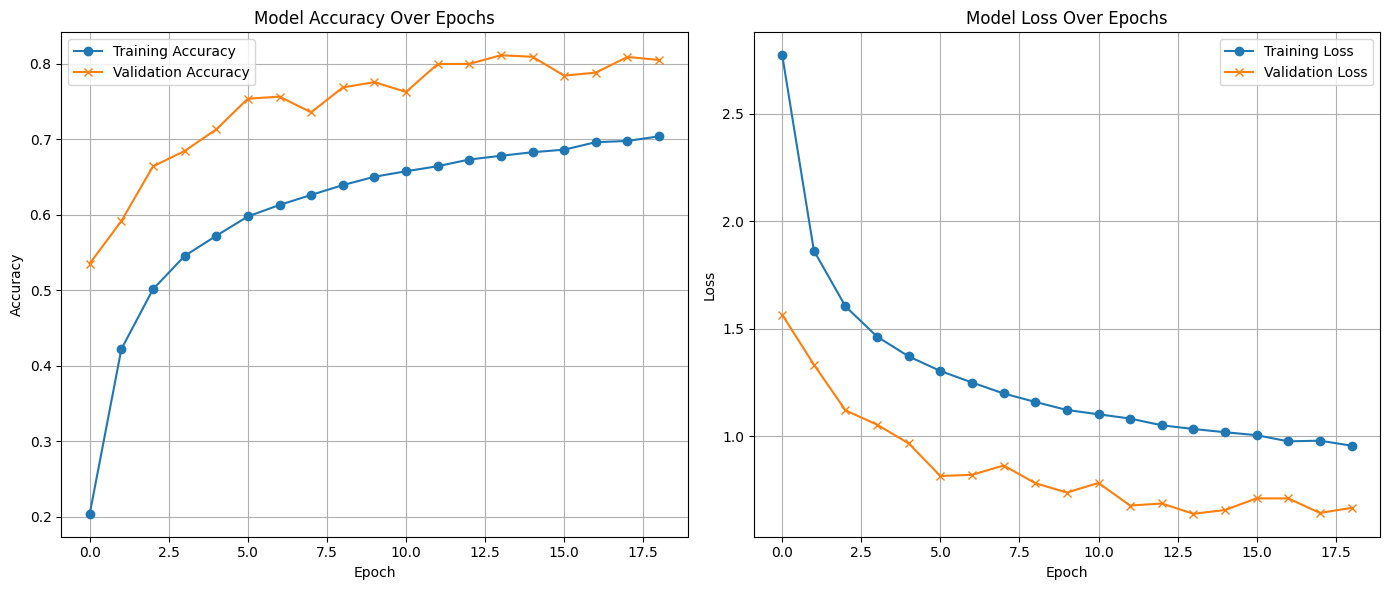

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


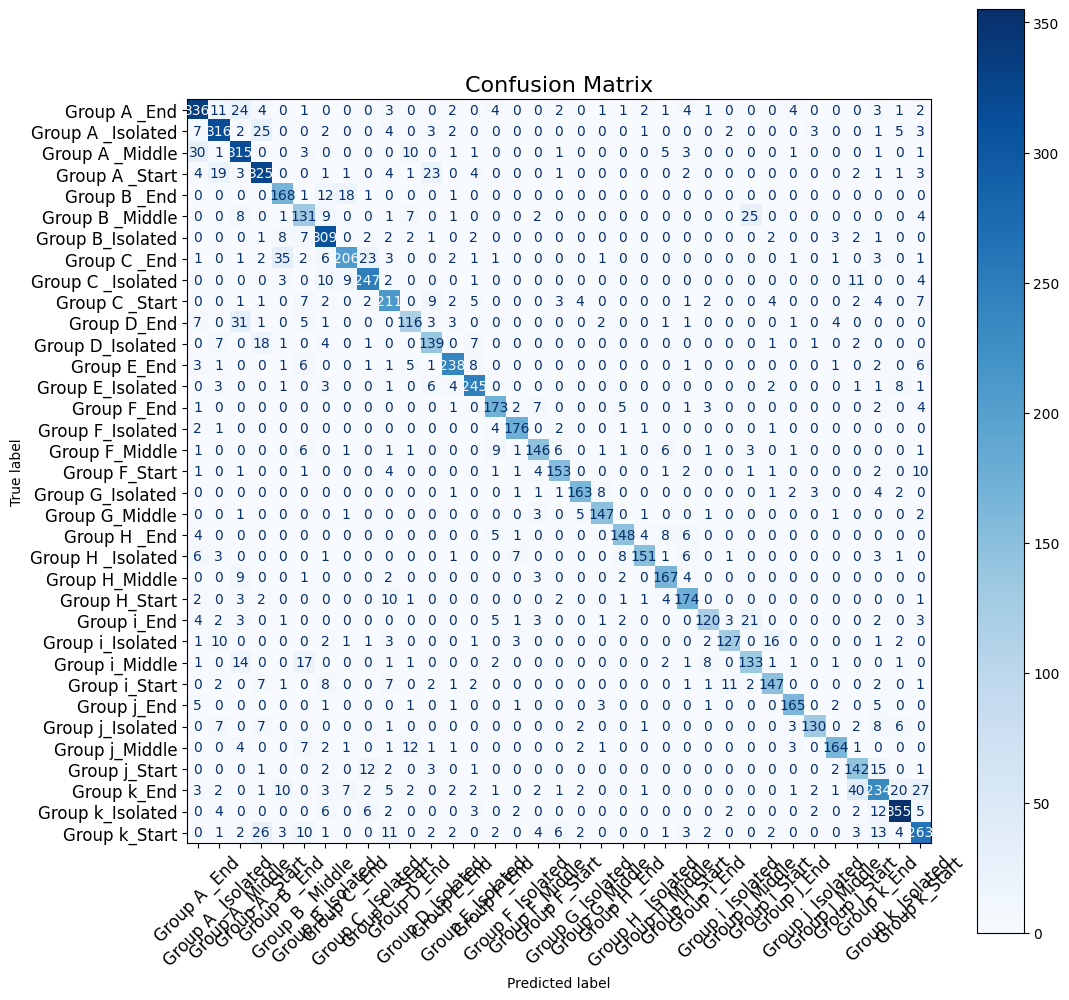

In [5]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix', fontsize=16)
ax.set_xticklabels(group_names, fontsize=12, rotation=45)
ax.set_yticklabels(group_names, fontsize=12)
plt.show()

## increase Batch size
## decrease Dropout

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 4"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 48s 33ms/step - accuracy: 0.1400 - loss: 3.0885 - val_accuracy: 0.5242 - val_loss: 1.5563
Epoch 2/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.4759 - loss: 1.6966 - val_accuracy: 0.6415 - val_loss: 1.1506
Epoch 3/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.5873 - loss: 1.3223 - val_accuracy: 0.7271 - val_loss: 0.8813
Epoch 4/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.6393 - loss: 1.1588 - val_accuracy: 0.6743 - val_loss: 1.0645
Epoch 5/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.6738 - loss: 1.0415 - val_accuracy: 0.7491 - val_loss: 0.8191
Epoch 6/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6941 - loss: 0.9796 - val_accuracy: 0.7886 - val_loss: 0.6926
Epoch 7/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.7046 - loss: 0.9315 - val_accuracy: 0.7907 - val_loss: 0.6674
Epoch 8/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.7237 - loss: 0.88

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8472 - loss: 0.5172
Train Accuracy: 80.78%
Test Accuracy: 85.09%


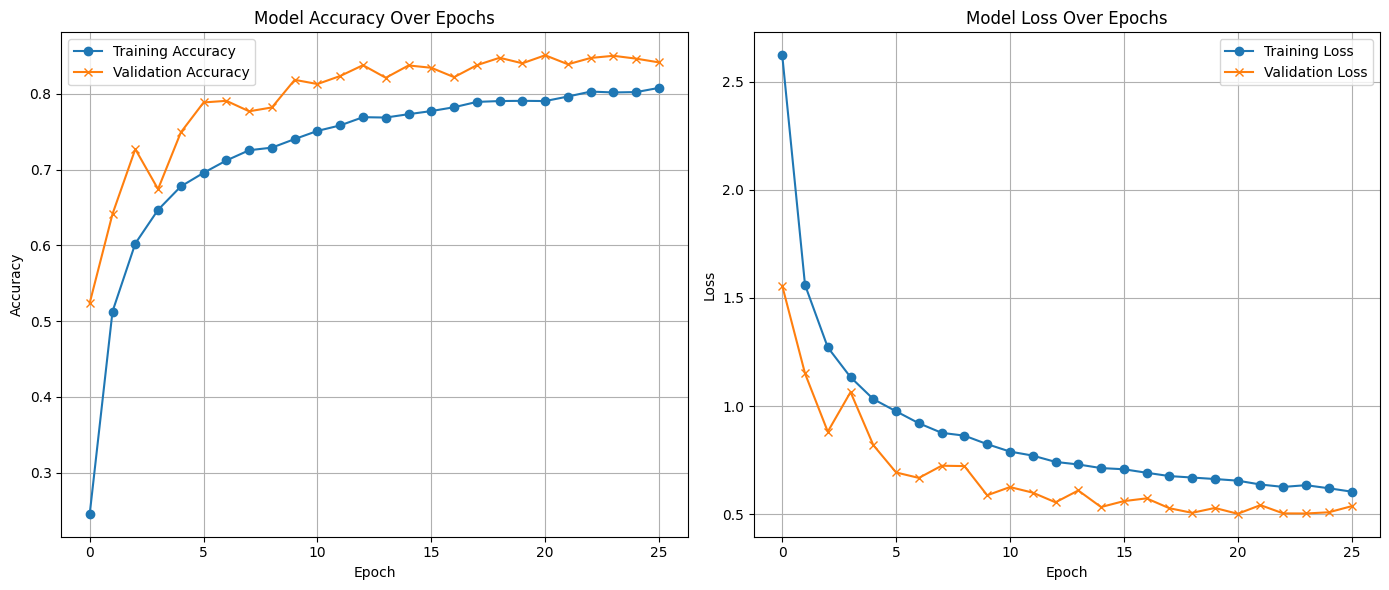

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


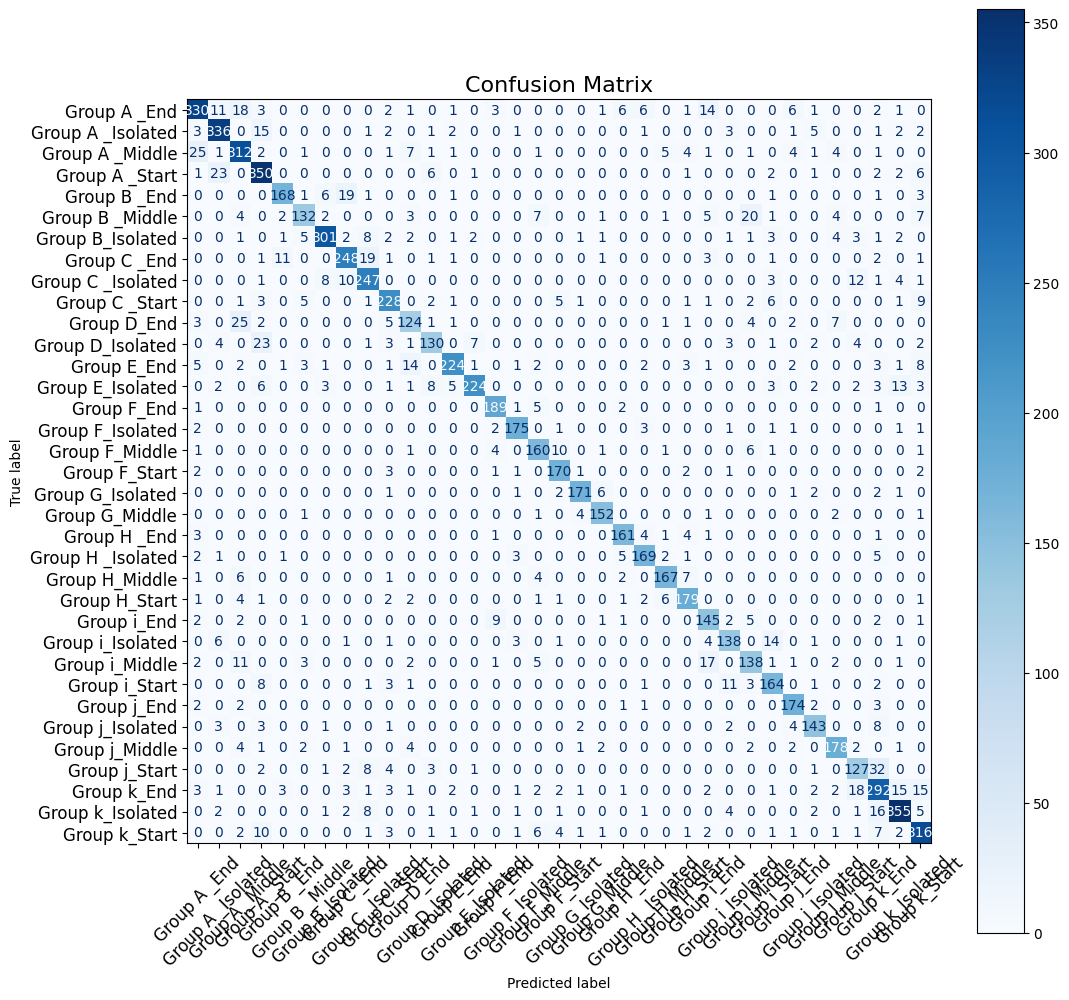

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix', fontsize=16)
ax.set_xticklabels(group_names, fontsize=12, rotation=45)
ax.set_yticklabels(group_names, fontsize=12)
plt.show()

### Delete DropOut

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 4"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - accuracy: 0.1885 - loss: 2.8990 - val_accuracy: 0.5713 - val_loss: 1.3949
Epoch 2/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 77s 30ms/step - accuracy: 0.5884 - loss: 1.3250 - val_accuracy: 0.6788 - val_loss: 1.0294
Epoch 3/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.6806 - loss: 1.0213 - val_accuracy: 0.7439 - val_loss: 0.8259
Epoch 4/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.7202 - loss: 0.8946 - val_accuracy: 0.7745 - val_loss: 0.7305
Epoch 5/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.7412 - loss: 0.8340 - val_accuracy: 0.7738 - val_loss: 0.7429
Epoch 6/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.7584 - loss: 0.7724 - val_accuracy: 0.7925 - val_loss: 0.6827
Epoch 7/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.7705 - loss: 0.7322 - val_accuracy: 0.8101 - val_loss: 0.6406
Epoch 8/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.7816 - loss: 0.69

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8642 - loss: 0.4607
Train Accuracy: 86.09%
Test Accuracy: 86.41%


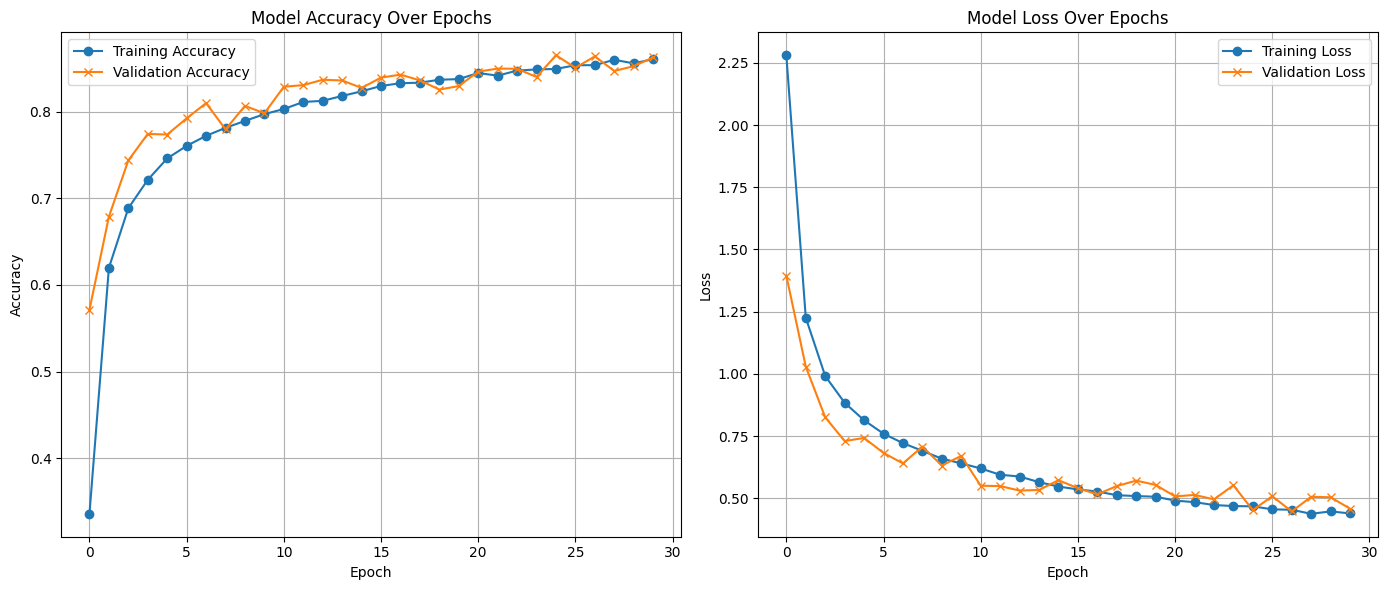

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


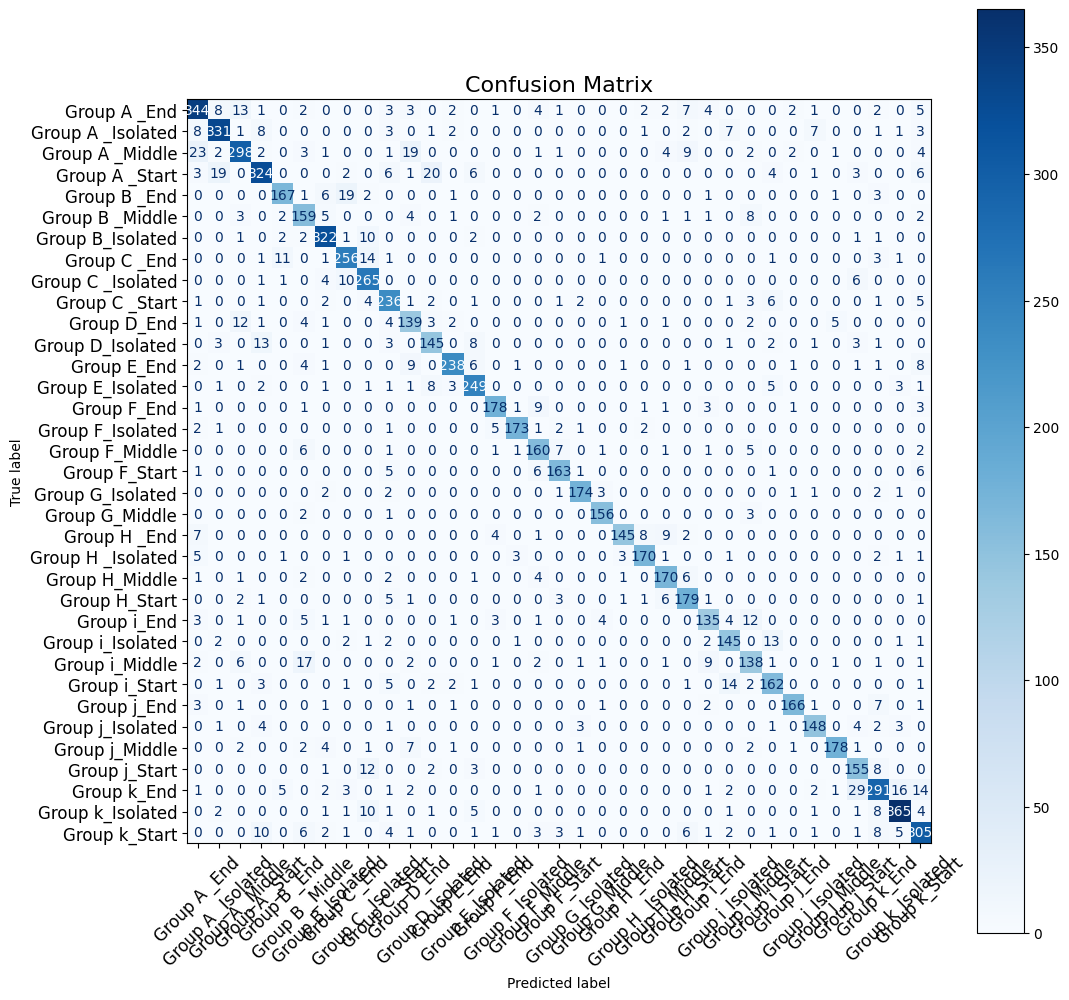

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix', fontsize=16)
ax.set_xticklabels(group_names, fontsize=12, rotation=45)
ax.set_yticklabels(group_names, fontsize=12)
plt.show()

In [ ]:
model.save('cnn4_model.keras')


In [ ]:
import os
data_dir = "/content/experience 4"
def count_images(data_dir):
    group_counts = {}
    for group_name in sorted(os.listdir(data_dir)):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
           total_images = 0
           for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    num_images = len(os.listdir(subfolder_path))
                    total_images += num_images
                    print(f"num of pic{group_name}/{subfolder}: {num_images}")
                    group_counts[group_name] = total_images
    return group_counts

group_counts = count_images(data_dir)
print("\nTotal number:", group_counts)

num of picGroup A _End/Thaa_End: 475
num of picGroup A _End/Taa_End: 469
num of picGroup A _End/Baa_End: 467
num of picGroup A _End/Non_End: 468
num of picGroup A _Isolated/Taa_Isolated: 467
num of picGroup A _Isolated/Thaa_Isolated: 457
num of picGroup A _Isolated/Non_Isolated: 466
num of picGroup A _Isolated/Baa_Isolated: 468
num of picGroup A _Middle/Taa_Middle: 462
num of picGroup A _Middle/Thaa_Middle: 467
num of picGroup A _Middle/Baa_Middle: 460
num of picGroup A _Middle/Non_Middle: 460
num of picGroup A _Start/Baa_Start: 473
num of picGroup A _Start/Taa_Start: 471
num of picGroup A _Start/Thaa_Start: 480
num of picGroup A _Start/Non_Start: 468
num of picGroup B _End/Ain_End: 460
num of picGroup B _End/Gen_End: 459
num of picGroup B _Middle/Gen_Middle: 458
num of picGroup B _Middle/Ain_Middle: 471
num of picGroup B_Isolated/Gen_Isolated: 920
num of picGroup B_Isolated/Ain_Isolated: 462
num of picGroup B_Isolated/Ain_Start: 462
num of picGroup C _End/Haa_End: 476
num of picGroup 